In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("Student_Performance_Dataset.csv")

In [3]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 

In [5]:
df.describe()

,Age,Class,Study_Hours_Per_Day,Attendance_Percentage,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,16.508800,10.496400,3.287260,74.919800,67.754800,66.895400,67.782800,67.282200,67.477656
std,1.718637,1.106812,1.587979,14.673842,18.724487,19.141195,19.248473,16.157511,10.964081
min,14.000000,9.000000,0.500000,50.000000,35.000000,35.000000,35.000000,40.000000,36.330000
25%,15.000000,10.000000,1.900000,62.000000,52.000000,50.000000,51.000000,53.000000,59.670000
50%,17.000000,10.000000,3.300000,75.000000,68.000000,67.000000,68.000000,67.000000,67.330000
75%,18.000000,11.000000,4.700000,88.000000,84.000000,83.000000,85.000000,81.000000,75.330000
max,19.000000,12.000000,6.000000,100.000000,100.000000,100.000000,100.000000,95.000000,98.330000


In [6]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Class,0
Study_Hours_Per_Day,0
Attendance_Percentage,0
Parental_Education,0
Internet_Access,0
Extracurricular_Activities,0
Math_Score,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df.columns)

Index(['Student_ID', 'Age', 'Gender', 'Class', 'Study_Hours_Per_Day',
       'Attendance_Percentage', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Math_Score', 'Science_Score',
       'English_Score', 'Previous_Year_Score', 'Final_Percentage',
       'Performance_Level', 'Pass_Fail'],
      dtype='object')


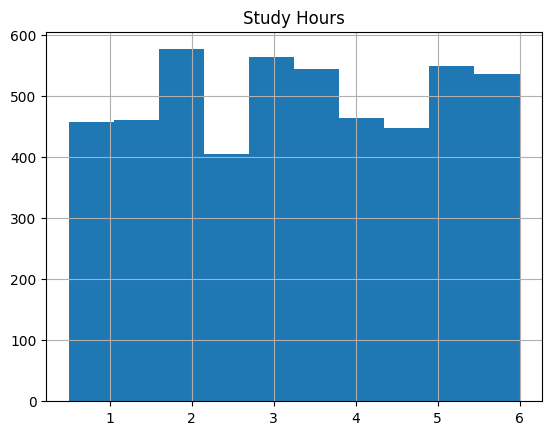

In [10]:
df["Study_Hours_Per_Day"].hist()
plt.title("Study Hours")
plt.show()

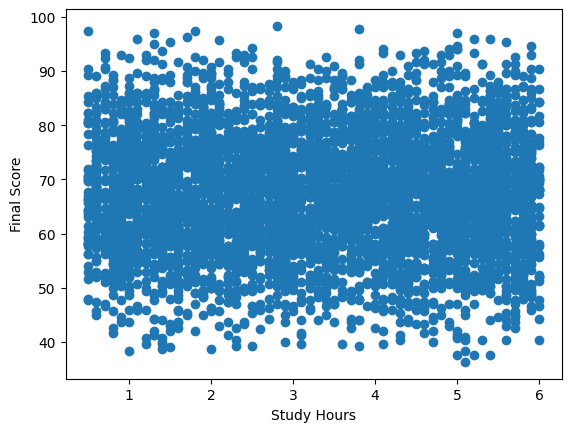

In [11]:
plt.scatter(df["Study_Hours_Per_Day"], df["Final_Percentage"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

In [12]:
print(df.corr(numeric_only=True))

                            Age     Class  Study_Hours_Per_Day  \
Age                    1.000000 -0.006924            -0.000666   
Class                 -0.006924  1.000000            -0.001648   
Study_Hours_Per_Day   -0.000666 -0.001648             1.000000   
Attendance_Percentage  0.019339 -0.034794             0.026916   
Math_Score             0.015123 -0.021287             0.016371   
Science_Score         -0.005807 -0.000277            -0.038413   
English_Score          0.001255 -0.005727             0.000122   
Previous_Year_Score    0.014855 -0.010855             0.019662   
Final_Percentage       0.005963 -0.015629            -0.012958   

                       Attendance_Percentage  Math_Score  Science_Score  \
Age                                 0.019339    0.015123      -0.005807   
Class                              -0.034794   -0.021287      -0.000277   
Study_Hours_Per_Day                 0.026916    0.016371      -0.038413   
Attendance_Percentage               1.0

In [13]:
X = df[["Study_Hours_Per_Day", "Attendance_Percentage"]]
y = df["Final_Percentage"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
predictions = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 8.932661948041401
R² Score: -0.0018156704471559149


In [18]:
new_student = [[6, 90]]
prediction = model.predict(new_student)
print(prediction)

[67.46925434]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
import joblib
joblib.dump(model, "student_model.pkl")

['student_model.pkl']